Uploading Dataset

# ASL Model Training






In [ ]:
from google.colab import files
files.upload()

Saving kaggle (1).json to kaggle (1).json


{'kaggle (1).json': b'{"username":"cclairee","key":"a4a6e0debb9b716330377d324848b987"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp "kaggle (1).json" ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d grassknoted/asl-alphabet
!unzip -q asl-alphabet.zip -d asl_dataset



Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
 97% 1.00G/1.03G [00:08<00:00, 357MB/s]
100% 1.03G/1.03G [00:08<00:00, 129MB/s]


In [ ]:
#Move test items to individual class subfolders
import os
import shutil

test_dir = 'asl_dataset/asl_alphabet_test/asl_alphabet_test'
for filename in os.listdir(test_dir):
    if filename.endswith('.jpg') or filename.endswith('.png'):
        label = filename[0]  # Assumes first character is the class label
        label_dir = os.path.join(test_dir, label)
        os.makedirs(label_dir, exist_ok=True)
        shutil.move(os.path.join(test_dir, filename), os.path.join(label_dir, filename))


In [ ]:
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

IMAGE_SIZE = (64, 64)
BATCH_SIZE = 32 # May want to test with 16

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_generator = datagen.flow_from_directory(
    '/content/asl_dataset/asl_alphabet_train/asl_alphabet_train',
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

label_map = train_generator.class_indices
inv_label_map = {v: k for k, v in label_map.items()}

test_generator = datagen.flow_from_directory(
    '/content/asl_dataset/asl_alphabet_train/asl_alphabet_train', # Changed directory to use training data for validation
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation' # Use the validation subset
)

Found 69600 images belonging to 29 classes.
Found 17400 images belonging to 29 classes.


In [ ]:
model = Sequential([
    Input(shape=(64, 64, 3)),
    Conv2D(32, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(pool_size=(2,2)),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.3),

    Dense(train_generator.num_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=10, # Bump this back up to 10 or 20 to get more accuracy
    validation_data=test_generator
)

loss, accuracy = model.evaluate(test_generator)
print(f"Test Accuracy: {accuracy:.2f}")

model.save("aslmodel.h5") #Can be saved as aslmodel.keras

#newly added
from tensorflow.keras.models import load_model
model = load_model("aslmodel.h5")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2175/2175 ━━━━━━━━━━━━━━━━━━━━ 394s 180ms/step - accuracy: 0.4580 - loss: 1.8542 - val_accuracy: 0.6744 - val_loss: 1.0594
544/544 ━━━━━━━━━━━━━━━━━━━━ 31s 56ms/step - accuracy: 0.6714 - loss: 1.0543


Test Accuracy: 0.67


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image as PILImage

IMAGE_SIZE = (64, 64)
label_map = train_generator.class_indices
inv_label_map = {v: k for k, v in label_map.items()}
def predict_asl_sign(img_path, model):
    try:
        img = PILImage.open(img_path).convert('RGB')
        img = img.resize(IMAGE_SIZE)

        img_array = image.img_to_array(img) / 255.0
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension

        # Predict
        prediction = model.predict(img_array)

        # for debugging

        print(f"Prediction shape: {prediction.shape}")
        print(f"Prediction output: {prediction}")

        if prediction.shape[1] == 1:
          predicted_class = int(prediction[0][0] > 0.5)  # Binary classification
          predicted_label = inv_label_map[predicted_class]
        else:
          predicted_class = np.argmax(prediction)
          predicted_label = inv_label_map[predicted_class]
        return predicted_label


    except Exception as e:
        print(f"❌ Error during prediction: {e}")
        return "Error"




Saving A_test.jpg to A_test.jpg


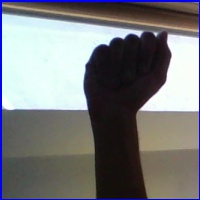

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Prediction shape: (1, 29)
Prediction output: [[7.28767335e-01 1.80594939e-09 9.12636366e-09 9.44058942e-10
  5.69041404e-05 4.03151651e-10 1.46351001e-16 1.18360670e-21
  1.26113865e-12 5.68446996e-14 1.67294530e-14 2.32350048e-05
  3.71240377e-02 2.71888734e-06 1.86108775e-03 5.30908732e-15
  2.97615856e-11 5.15337382e-12 2.32007980e-01 1.29809114e-05
  2.51837395e-09 1.53831614e-08 1.87839255e-08 1.45580625e-05
  6.73997874e-06 1.22480924e-04 1.98265293e-09 2.56766815e-16
  4.00613584e-14]]
Prediction for 'A_test.jpg': A


In [ ]:
from google.colab import files
from IPython.display import Image as IPyImage, display

uploaded = files.upload()

for filename in uploaded.keys():
    display(IPyImage(filename))
    result = predict_asl_sign(filename, model)
    print(f"Prediction for '{filename}': {result}")
